<a href="https://colab.research.google.com/github/AdeelAsghar11/deep-learning-playground/blob/main/keras_medical_tumor_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [27]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [28]:
train_dir = path + "/Training"
test_dir = path + "/Testing"

In [29]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [30]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    color_mode='grayscale'
)

Found 5600 images belonging to 4 classes.


In [31]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    color_mode='grayscale'
)

Found 1600 images belonging to 4 classes.


In [32]:
print(train_generator.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [33]:
from tensorflow.keras.model_optimizeds import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [34]:
model = Sequential()

# 🔹 Convolution Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(256,256,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

# 🔹 Convolution Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# 🔹 Convolution Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# 🔹 Flatten
model.add(Flatten())

# 🔹 Fully Connected Layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))   # prevents overfitting

# 🔹 Output Layer (4 classes)
model.add(Dense(4, activation='softmax'))

In [35]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [36]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,838,916 (56.61 MB)

 Trainable params: 14,838,916 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 46s 207ms/step - accuracy: 0.6768 - loss: 0.7778 - val_accuracy: 0.7394 - val_loss: 0.7623
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - accuracy: 0.8302 - loss: 0.4474 - val_accuracy: 0.7675 - val_loss: 0.7495
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step - accuracy: 0.8704 - loss: 0.3370 - val_accuracy: 0.7812 - val_loss: 0.9003
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 89ms/step - accuracy: 0.8980 - loss: 0.2664 - val_accuracy: 0.8356 - val_loss: 0.9083
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - accuracy: 0.9245 - loss: 0.1977 - val_accuracy: 0.8631 - val_loss: 0.7933
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 94ms/step - accuracy: 0.9455 - loss: 0.1485 - val_accuracy: 0.8512 - val_loss: 1.0311
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 94ms/step - accuracy: 0.9511 - loss: 0.1357 - val_accuracy: 0.8850 - val_loss: 0.8450
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 94ms/step - accuracy: 0.9636 - loss: 0.1063 -

In [42]:
from tensorflow.keras.layers import BatchNormalization

model_optimized = Sequential()

# 🔹 Block 1
model_optimized.add(Conv2D(32, (3,3), activation='relu', input_shape=(256,256,1)))
model_optimized.add(BatchNormalization())   # 🔥 NEW
model_optimized.add(MaxPooling2D(2,2))
model_optimized.add(Dropout(0.25))          # 🔥 NEW

# 🔹 Block 2
model_optimized.add(Conv2D(64, (3,3), activation='relu'))
model_optimized.add(BatchNormalization())
model_optimized.add(MaxPooling2D(2,2))
model_optimized.add(Dropout(0.25))

# 🔹 Block 3
model_optimized.add(Conv2D(128, (3,3), activation='relu'))
model_optimized.add(BatchNormalization())
model_optimized.add(MaxPooling2D(2,2))
model_optimized.add(Dropout(0.25))

# 🔹 Fully Connected
model_optimized.add(Flatten())

model_optimized.add(Dense(128, activation='relu'))
model_optimized.add(BatchNormalization())
model_optimized.add(Dropout(0.5))   # stronger dropout here

# 🔹 Output
model_optimized.add(Dense(4, activation='softmax'))

In [43]:
model_optimized.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [44]:
history = model_optimized.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 29s 124ms/step - accuracy: 0.7632 - loss: 0.6577 - val_accuracy: 0.2500 - val_loss: 52.1487
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 99ms/step - accuracy: 0.8673 - loss: 0.3599 - val_accuracy: 0.3244 - val_loss: 7.5471
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - accuracy: 0.9137 - loss: 0.2426 - val_accuracy: 0.6263 - val_loss: 1.5066
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 96ms/step - accuracy: 0.9339 - loss: 0.1849 - val_accuracy: 0.5169 - val_loss: 4.5223
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 18s 100ms/step - accuracy: 0.9289 - loss: 0.1865 - val_accuracy: 0.7369 - val_loss: 1.1144
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - accuracy: 0.9550 - loss: 0.1252 - val_accuracy: 0.6888 - val_loss: 1.4301
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - accuracy: 0.9680 - loss: 0.0938 - val_accuracy: 0.7994 - val_loss: 0.7834
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - accuracy: 0.9764 - loss: 0.0655

In [45]:
from tensorflow.keras.callbacks import EarlyStopping

In [50]:
from tensorflow.keras.layers import BatchNormalization

model_optimized2 = Sequential()

# 🔹 Block 1
model_optimized2.add(Conv2D(32, (3,3), activation='relu', input_shape=(256,256,1)))
model_optimized2.add(BatchNormalization())   # 🔥 NEW
model_optimized2.add(MaxPooling2D(2,2))
model_optimized2.add(Dropout(0.25))          # 🔥 NEW

# 🔹 Block 2
model_optimized2.add(Conv2D(64, (3,3), activation='relu'))
model_optimized2.add(BatchNormalization())
model_optimized2.add(MaxPooling2D(2,2))
model_optimized2.add(Dropout(0.25))

# 🔹 Block 3
model_optimized2.add(Conv2D(128, (3,3), activation='relu'))
model_optimized2.add(BatchNormalization())
model_optimized2.add(MaxPooling2D(2,2))
model_optimized2.add(Dropout(0.25))

# 🔹 Fully Connected
model_optimized2.add(Flatten())

model_optimized2.add(Dense(128, activation='relu'))
model_optimized2.add(BatchNormalization())
model_optimized2.add(Dropout(0.5))   # stronger dropout here

# 🔹 Output
model_optimized2.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [53]:
model_optimized2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [54]:
early_stop = EarlyStopping(
    monitor='val_loss',        # watch validation loss
    patience=3,                # wait 3 epochs before stopping
    restore_best_weights=True  # 🔥 VERY IMPORTANT
)

In [55]:
history = model_optimized2.fit(
    train_generator,
    epochs=20,                 # increase epochs (early stopping will handle it)
    validation_data=test_generator,
    callbacks=[early_stop]
)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 27s 112ms/step - accuracy: 0.7675 - loss: 0.6422 - val_accuracy: 0.2500 - val_loss: 20.2293
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 18s 100ms/step - accuracy: 0.8595 - loss: 0.3851 - val_accuracy: 0.1562 - val_loss: 6.8319
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 18s 100ms/step - accuracy: 0.8975 - loss: 0.2909 - val_accuracy: 0.5263 - val_loss: 4.0974
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 96ms/step - accuracy: 0.9323 - loss: 0.1959 - val_accuracy: 0.7613 - val_loss: 1.7862
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - accuracy: 0.9479 - loss: 0.1463 - val_accuracy: 0.7519 - val_loss: 1.6332
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 18s 100ms/step - accuracy: 0.9691 - loss: 0.0975 - val_accuracy: 0.8550 - val_loss: 0.7468
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - accuracy: 0.9729 - loss: 0.0809 - val_accuracy: 0.8394 - val_loss: 3.1911
Epoch 8/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - accuracy: 0.9736 - loss: 0.07

In [56]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [79]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [80]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    color_mode='grayscale'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    color_mode='grayscale'
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [81]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

In [82]:
model_augmented = Sequential()

# 🔹 Block 1
model_augmented.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,1)))
model_augmented.add(BatchNormalization())
model_augmented.add(MaxPooling2D(2,2))

# 🔹 Block 2
model_augmented.add(Conv2D(64, (3,3), activation='relu'))
model_augmented.add(BatchNormalization())
model_augmented.add(MaxPooling2D(2,2))

# 🔹 Block 3
model_augmented.add(Conv2D(128, (3,3), activation='relu'))
model_augmented.add(BatchNormalization())
model_augmented.add(MaxPooling2D(2,2))

# 🔹 Block 4
model_augmented.add(Conv2D(256, (3,3), activation='relu'))
model_augmented.add(BatchNormalization())
model_augmented.add(MaxPooling2D(2,2))

# 🔹 Dense
model_augmented.add(Flatten())

model_augmented.add(Dense(256, activation='relu'))
model_augmented.add(BatchNormalization())
model_augmented.add(Dropout(0.5))

# 🔹 Output
model_augmented.add(Dense(4, activation='softmax'))

In [86]:
from tensorflow.keras.optimizers import Adam
model_augmented.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [87]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
early_stop = EarlyStopping(
    monitor='val_loss',        # stop when validation loss stops improving
    patience=7,                # wait 4 epochs before stopping
    restore_best_weights=True  # restore the best model weights
)

In [88]:
checkpoint = ModelCheckpoint(
    "best_model_augmented.h5",  # file to save best model
    monitor='val_loss',          # monitor validation loss
    save_best_only=True,         # save only the best model
    verbose=1
)

In [89]:
history = model_augmented.fit(
    train_generator,
    epochs=25,
    validation_data=test_generator,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.6648 - loss: 0.9999
Epoch 1: val_loss improved from None to 6.29570, saving model to best_model_augmented.h5



Epoch 1: finished saving model to best_model_augmented.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 45s 216ms/step - accuracy: 0.7198 - loss: 0.8049 - val_accuracy: 0.2500 - val_loss: 6.2957
Epoch 2/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.7854 - loss: 0.5795
Epoch 2: val_loss improved from 6.29570 to 2.83123, saving model to best_model_augmented.h5



Epoch 2: finished saving model to best_model_augmented.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 37s 212ms/step - accuracy: 0.7957 - loss: 0.5500 - val_accuracy: 0.2763 - val_loss: 2.8312
Epoch 3/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.8374 - loss: 0.4597
Epoch 3: val_loss improved from 2.83123 to 1.42466, saving model to best_model_augmented.h5



Epoch 3: finished saving model to best_model_augmented.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 37s 213ms/step - accuracy: 0.8396 - loss: 0.4477 - val_accuracy: 0.5981 - val_loss: 1.4247
Epoch 4/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.8538 - loss: 0.3981
Epoch 4: val_loss improved from 1.42466 to 0.94131, saving model to best_model_augmented.h5



Epoch 4: finished saving model to best_model_augmented.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 37s 211ms/step - accuracy: 0.8514 - loss: 0.4128 - val_accuracy: 0.7444 - val_loss: 0.9413
Epoch 5/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.8501 - loss: 0.3977
Epoch 5: val_loss improved from 0.94131 to 0.89819, saving model to best_model_augmented.h5



Epoch 5: finished saving model to best_model_augmented.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 38s 215ms/step - accuracy: 0.8645 - loss: 0.3693 - val_accuracy: 0.7412 - val_loss: 0.8982
Epoch 6/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.8870 - loss: 0.3262
Epoch 6: val_loss did not improve from 0.89819
175/175 ━━━━━━━━━━━━━━━━━━━━ 37s 209ms/step - accuracy: 0.8829 - loss: 0.3326 - val_accuracy: 0.7519 - val_loss: 0.9669
Epoch 7/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.8839 - loss: 0.3091
Epoch 7: val_loss improved from 0.89819 to 0.69667, saving model to best_model_augmented.h5



Epoch 7: finished saving model to best_model_augmented.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 37s 209ms/step - accuracy: 0.8907 - loss: 0.2994 - val_accuracy: 0.8106 - val_loss: 0.6967
Epoch 8/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.8988 - loss: 0.2612
Epoch 8: val_loss did not improve from 0.69667
175/175 ━━━━━━━━━━━━━━━━━━━━ 36s 206ms/step - accuracy: 0.8973 - loss: 0.2712 - val_accuracy: 0.6775 - val_loss: 1.8621
Epoch 9/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9081 - loss: 0.2702
Epoch 9: val_loss did not improve from 0.69667
175/175 ━━━━━━━━━━━━━━━━━━━━ 36s 205ms/step - accuracy: 0.8980 - loss: 0.2900 - val_accuracy: 0.7675 - val_loss: 0.8880
Epoch 10/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.8969 - loss: 0.2773
Epoch 10: val_loss improved from 0.69667 to 0.61489, saving model to best_model_augmented.h5



Epoch 10: finished saving model to best_model_augmented.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 36s 206ms/step - accuracy: 0.9021 - loss: 0.2613 - val_accuracy: 0.8525 - val_loss: 0.6149
Epoch 11/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.9196 - loss: 0.2285
Epoch 11: val_loss improved from 0.61489 to 0.55912, saving model to best_model_augmented.h5



Epoch 11: finished saving model to best_model_augmented.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 35s 202ms/step - accuracy: 0.9150 - loss: 0.2378 - val_accuracy: 0.8744 - val_loss: 0.5591
Epoch 12/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.9216 - loss: 0.2116
Epoch 12: val_loss did not improve from 0.55912
175/175 ━━━━━━━━━━━━━━━━━━━━ 35s 199ms/step - accuracy: 0.9239 - loss: 0.2133 - val_accuracy: 0.7675 - val_loss: 0.8800
Epoch 13/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.9297 - loss: 0.2071
Epoch 13: val_loss improved from 0.55912 to 0.49246, saving model to best_model_augmented.h5



Epoch 13: finished saving model to best_model_augmented.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 36s 207ms/step - accuracy: 0.9279 - loss: 0.2113 - val_accuracy: 0.8950 - val_loss: 0.4925
Epoch 14/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9397 - loss: 0.1709
Epoch 14: val_loss did not improve from 0.49246
175/175 ━━━━━━━━━━━━━━━━━━━━ 36s 204ms/step - accuracy: 0.9359 - loss: 0.1816 - val_accuracy: 0.8325 - val_loss: 0.6114
Epoch 15/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9517 - loss: 0.1563
Epoch 15: val_loss did not improve from 0.49246
175/175 ━━━━━━━━━━━━━━━━━━━━ 36s 205ms/step - accuracy: 0.9468 - loss: 0.1572 - val_accuracy: 0.7725 - val_loss: 0.8985
Epoch 16/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9381 - loss: 0.1736
Epoch 16: val_loss did not improve from 0.49246
175/175 ━━━━━━━━━━━━━━━━━━━━ 36s 204ms/step - accuracy: 0.9361 - loss: 0.1787 - val_accuracy: 0.8913 - val_loss: 0.5393
Epoch 17/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms

In [90]:
# Best training accuracy and loss
best_train_acc = max(history.history['accuracy'])
best_train_loss = min(history.history['loss'])

# Best validation accuracy and loss
best_val_acc = max(history.history['val_accuracy'])
best_val_loss = min(history.history['val_loss'])

print(f"Best Training Accuracy: {best_train_acc:.4f}")
print(f"Best Training Loss: {best_train_loss:.4f}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Best Validation Loss: {best_val_loss:.4f}")

Best Training Accuracy: 0.9491
Best Training Loss: 0.1336
Best Validation Accuracy: 0.8950
Best Validation Loss: 0.4925


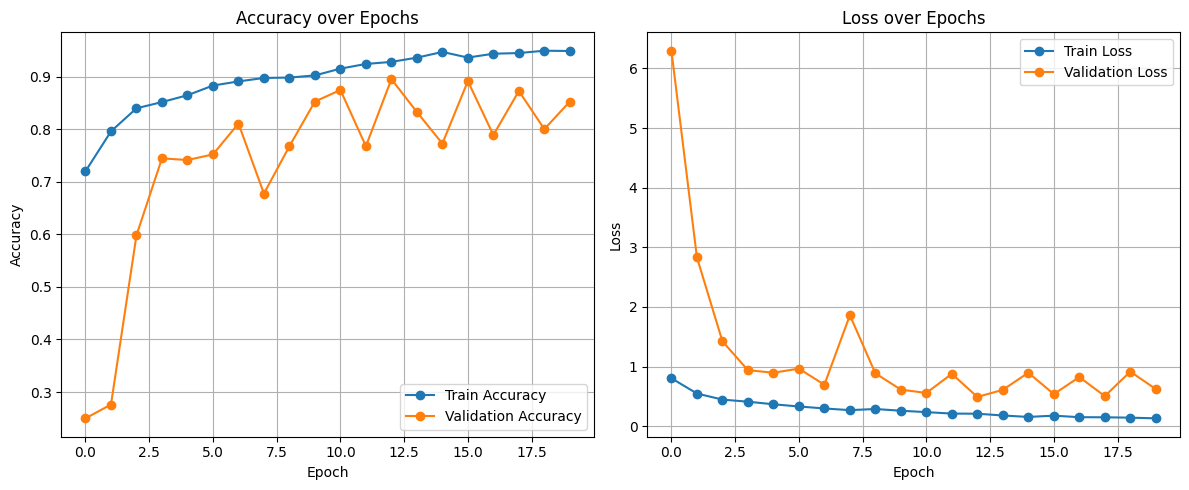

In [91]:
import matplotlib.pyplot as plt

# Accuracy curve
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss curve
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()